In [5]:
import sys
from pathlib import Path
from typing import Union

# Ensure project root is on sys.path
_project_root = str(Path("__file__").resolve().parent.parent) if "__file__" in dir() else str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.impute import KNNImputer

from common import Wildcards, training_samples, val_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files


# Inlined from select_features.py (can't import directly because
# fire.Fire(Conf) at module level clashes with Jupyter kernel args)
def get_hvg(input_df: pd.DataFrame, top_n: Union[int, float] = 500) -> pd.DataFrame:
    """Keep top_n highest-variance features after removing bottom 20% by mean."""
    means = np.mean(input_df, axis=0)
    threshold = np.percentile(means, 20)
    input_df = input_df.loc[:, means >= threshold]
    if isinstance(top_n, int):
        top_n = min(top_n, input_df.shape[1])
        var_threshold = sorted(np.nanvar(input_df, axis=0), reverse=True)[top_n - 1]
        input_df = input_df.loc[:, np.nanvar(input_df, axis=0) >= var_threshold]
    elif isinstance(top_n, float):
        perc = 100 * top_n
        var_threshold = np.percentile(np.nanvar(input_df, axis=0), perc)
        input_df = input_df.loc[:, np.nanvar(input_df, axis=0) >= var_threshold]
    return input_df

## Load raw proteomics and transcriptomics data

In [6]:
model = "EGFR_MAPK__logobs"
data = "dream_cytof"

conf = Conf(model=model, data=data, context="transcriptomics", features="all", samples="all")
petab_base_files = load_petab_base_files(conf)
del petab_base_files["condition_table"]

samples_train = training_samples(Wildcards(data, "all"))
samples_val = val_samples(Wildcards(data, "all"))

In [7]:
# Load transcriptomics
tx_train_raw, tx_features, _, tx_imputer = load_data(
    contextualization="transcriptomics",
    samples=samples_train,
    features=None,
    **petab_base_files,
)

# Load proteomics
px_train_raw, px_features, _, px_imputer = load_data(
    contextualization="proteomics",
    samples=samples_train,
    features=None,
    **petab_base_files,
)

print(f"Transcriptomics: {tx_train_raw.shape[0]} samples x {tx_train_raw.shape[1]} genes")
print(f"Proteomics:      {px_train_raw.shape[0]} samples x {px_train_raw.shape[1]} proteins")

Transcriptomics: 58 samples x 16562 genes
Proteomics:      58 samples x 6161 proteins


In [8]:
# Impute + mean-center (same as select_features.py pipeline)
def prepare(df):
    imp = KNNImputer()
    filled = pd.DataFrame(imp.fit_transform(df), index=df.index, columns=df.columns)
    filled -= filled.mean()
    return filled

tx_train = prepare(tx_train_raw)
px_train = prepare(px_train_raw)

## Compare HVG prefilter: `top_n=500` vs `top_n=5000`

In [9]:
top_n_values = [500, 5000]
results = {}

for context_name, df in [("transcriptomics", tx_train), ("proteomics", px_train)]:
    results[context_name] = {}
    for top_n in top_n_values:
        hvg_df = get_hvg(df, top_n=top_n)
        n_after = hvg_df.shape[1]
        # Clamp to actual available if top_n exceeds post-mean-filter count
        results[context_name][top_n] = {
            "n_input": df.shape[1],
            "n_after_hvg": n_after,
            "genes": set(hvg_df.columns),
        }
        print(f"{context_name} | top_n={top_n:>5}: {df.shape[1]} -> {n_after} genes after HVG")

transcriptomics | top_n=  500: 16562 -> 500 genes after HVG
transcriptomics | top_n= 5000: 16562 -> 5000 genes after HVG
proteomics | top_n=  500: 6161 -> 500 genes after HVG
proteomics | top_n= 5000: 6161 -> 4985 genes after HVG


In [10]:
# Overlap between top_n=500 and top_n=5000
for context_name in ["transcriptomics", "proteomics"]:
    g500 = results[context_name][500]["genes"]
    g5000 = results[context_name][5000]["genes"]
    overlap = g500 & g5000
    only_500 = g500 - g5000
    only_5000 = g5000 - g500
    print(f"\n{context_name}:")
    print(f"  top_n=500:  {len(g500)} genes")
    print(f"  top_n=5000: {len(g5000)} genes")
    print(f"  overlap:    {len(overlap)}")
    print(f"  only in 5000: {len(only_5000)} extra genes")


transcriptomics:
  top_n=500:  500 genes
  top_n=5000: 5000 genes
  overlap:    500
  only in 5000: 4500 extra genes

proteomics:
  top_n=500:  500 genes
  top_n=5000: 4985 genes
  overlap:    500
  only in 5000: 4485 extra genes


## Variance distribution: where does top_n=500 cut?

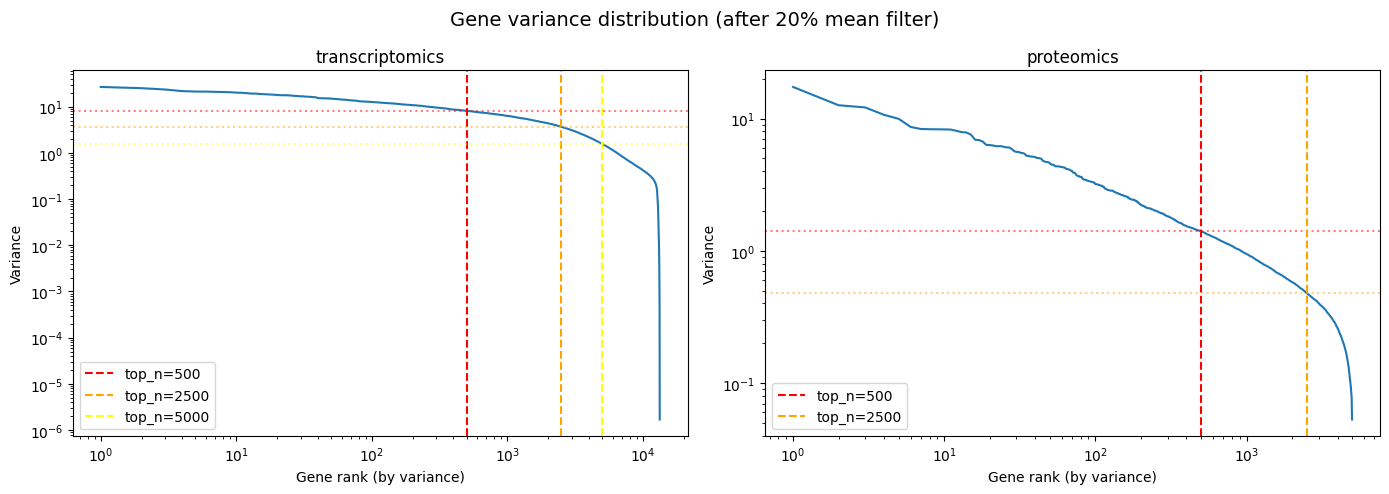

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (context_name, df) in zip(axes, [("transcriptomics", tx_train), ("proteomics", px_train)]):
    # Remove bottom 20% by mean (same as get_hvg)
    means = np.mean(df, axis=0)
    threshold = np.percentile(means, 20)
    df_filtered = df.loc[:, means >= threshold]

    variances = np.nanvar(df_filtered, axis=0)
    variances_sorted = np.sort(variances)[::-1]

    ax.plot(range(1, len(variances_sorted) + 1), variances_sorted, lw=1.5)

    for top_n, color in zip([500, 2500, 5000], ["red", "orange", "yellow"]):
        if top_n < len(variances_sorted):
            cutoff_var = variances_sorted[min(top_n, len(variances_sorted) - 1)]
            ax.axvline(top_n, color=color, ls="--", label=f"top_n={top_n}")
            ax.axhline(cutoff_var, color=color, ls=":", alpha=0.5)

    ax.set_xlabel("Gene rank (by variance)")
    ax.set_ylabel("Variance")
    ax.set_title(context_name)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()

fig.suptitle("Gene variance distribution (after 20% mean filter)", fontsize=14)
plt.tight_layout()
plt.show()

## Cumulative explained variance

How much total variance is captured as we increase the number of HVGs?

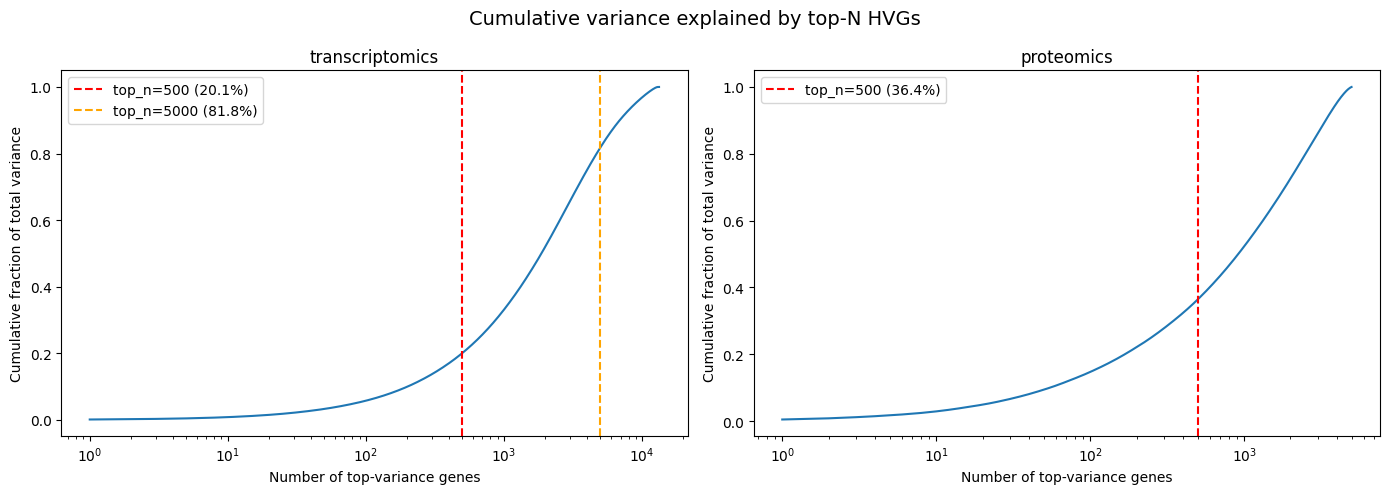

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (context_name, df) in zip(axes, [("transcriptomics", tx_train), ("proteomics", px_train)]):
    means = np.mean(df, axis=0)
    threshold = np.percentile(means, 20)
    df_filtered = df.loc[:, means >= threshold]

    variances = np.nanvar(df_filtered, axis=0)
    variances_sorted = np.sort(variances)[::-1]
    cum_var = np.cumsum(variances_sorted) / np.sum(variances_sorted)

    ax.plot(range(1, len(cum_var) + 1), cum_var, lw=1.5)

    for top_n, color in zip([500, 5000], ["red", "orange"]):
        if top_n < len(cum_var):
            ax.axvline(top_n, color=color, ls="--", label=f"top_n={top_n} ({cum_var[top_n-1]:.1%})")

    ax.set_xlabel("Number of top-variance genes")
    ax.set_ylabel("Cumulative fraction of total variance")
    ax.set_title(context_name)
    ax.set_xscale("log")
    ax.legend()

fig.suptitle("Cumulative variance explained by top-N HVGs", fontsize=14)
plt.tight_layout()
plt.show()

## Effective pool size for HVGRFE at various N

For each requested `N_features`, how many genes are actually available after the HVG prefilter?
If `N > pool_size`, the RFE can never reach the target — you just get all HVGs.

In [13]:
N_values = [4, 6, 8, 10, 12, 16, 20, 24, 28, 32, 64, 128, 256, 512, 1024, 2048, 4096]

rows = []
for context_name, df in [("transcriptomics", tx_train), ("proteomics", px_train)]:
    for top_n in [500, 5000]:
        hvg_df = get_hvg(df, top_n=top_n)
        pool = hvg_df.shape[1]
        for N in N_values:
            effective = min(N, pool)
            saturated = N >= pool
            rows.append({
                "context": context_name,
                "top_n": top_n,
                "requested_N": N,
                "HVG_pool": pool,
                "effective_N": effective,
                "saturated": saturated,
            })

pool_df = pd.DataFrame(rows)
pool_df

,context,top_n,requested_N,HVG_pool,effective_N,saturated
0,transcriptomics,500,4,500,4,False
1,transcriptomics,500,6,500,6,False
2,transcriptomics,500,8,500,8,False
3,transcriptomics,500,10,500,10,False
4,transcriptomics,500,12,500,12,False
...,...,...,...,...,...,...
63,proteomics,5000,256,4985,256,False
64,proteomics,5000,512,4985,512,False
65,proteomics,5000,1024,4985,1024,False
66,proteomics,5000,2048,4985,2048,False


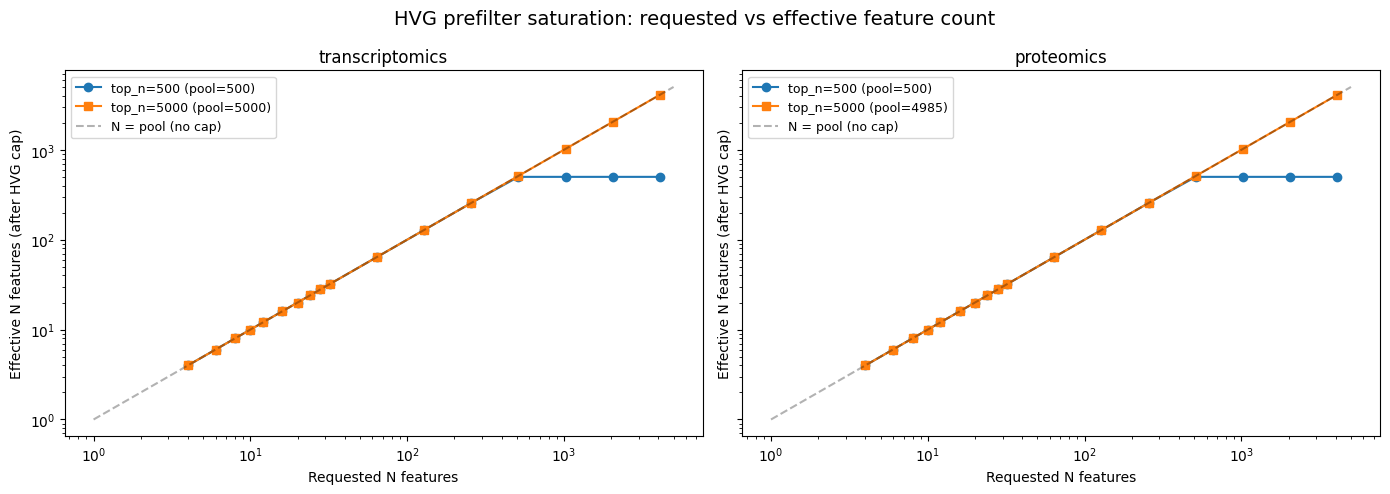

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, context_name in zip(axes, ["transcriptomics", "proteomics"]):
    sub = pool_df[pool_df.context == context_name]
    for top_n, marker, color in [(500, "o", "tab:blue"), (5000, "s", "tab:orange")]:
        s = sub[sub.top_n == top_n]
        ax.plot(s.requested_N, s.effective_N, marker=marker, color=color,
                label=f"top_n={top_n} (pool={s.HVG_pool.iloc[0]})")

    # Diagonal = no saturation
    ax.plot([1, 5000], [1, 5000], "k--", alpha=0.3, label="N = pool (no cap)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Requested N features")
    ax.set_ylabel("Effective N features (after HVG cap)")
    ax.set_title(context_name)
    ax.legend(fontsize=9)

fig.suptitle("HVG prefilter saturation: requested vs effective feature count", fontsize=14)
plt.tight_layout()
plt.show()

## Which saturation point?

Print the first N where the HVG pool becomes the bottleneck.

In [15]:
for context_name in ["transcriptomics", "proteomics"]:
    for top_n in [500, 5000]:
        sub = pool_df[(pool_df.context == context_name) & (pool_df.top_n == top_n)]
        sat = sub[sub.saturated]
        pool = sub.HVG_pool.iloc[0]
        if len(sat):
            first_sat_N = sat.requested_N.iloc[0]
            print(f"{context_name} | top_n={top_n:>5}: pool={pool:>5} genes -> saturates at N={first_sat_N}")
        else:
            print(f"{context_name} | top_n={top_n:>5}: pool={pool:>5} genes -> never saturates in scanned range")

transcriptomics | top_n=  500: pool=  500 genes -> saturates at N=512
transcriptomics | top_n= 5000: pool= 5000 genes -> never saturates in scanned range
proteomics | top_n=  500: pool=  500 genes -> saturates at N=512
proteomics | top_n= 5000: pool= 4985 genes -> never saturates in scanned range


## Summary

- With `top_n=500` (the current default), the HVG prefilter passes ~500 genes.
  Requesting `HVGRFE_512_permute` or higher effectively means RFE receives ≤500 candidates,
  so curves plateau because you can't select more features than the pool contains.

- With `top_n=5000`, the pool is much larger (though it may be capped by the total
  number of genes/proteins after the 20%-mean filter). This would allow RFE to
  meaningfully select among more candidates at higher N values.

- However, the variance distribution plots show whether those extra genes actually
  carry meaningful variance or are mostly noise — if cumulative variance is already
  near 100% at 500 genes, expanding the pool may not help.